In [2]:
import socket
import time
import json
import random
import csv

HOST = 'localhost'
PORT = 8000
NUM_ORDERS = 500000

import threading

NUM_THREADS = 1
ORDERS_PER_THREAD = NUM_ORDERS // NUM_THREADS

thread_rtts = [[] for _ in range(NUM_THREADS)]
thread_type_rtts = [{"NEW": [], "MODIFY": [], "CANCEL": []} for _ in range(NUM_THREADS)]

def thread_worker(thread_id):
    order_ids = []
    next_order_id = 1
    for _ in range(ORDERS_PER_THREAD):
        order_type = random.choices(["NEW", "MODIFY", "CANCEL"], weights=[0.7, 0.2, 0.1])[0]
        if order_type == "NEW" or not order_ids:
            order = {
                "Type": "NEW",
                "OrderId": next_order_id,
                "Pair": "BTC/USDT",
                "Price": str(random.randint(90000, 110000)),
                "Quantity": str(random.randint(1, 10)),
                "Side": random.choice(["BUY", "SELL"])
            }
            order_ids.append(next_order_id)
            next_order_id += 1
        elif order_type == "MODIFY":
            oid = random.choice(order_ids)
            order = {
                "Type": "MODIFY",
                "OrderId": oid,
                "Pair": "BTC/USDT",
                "Price": str(random.randint(90000, 110000)),
                "Quantity": str(random.randint(1, 10)),
                "Side": random.choice(["BUY", "SELL"])
            }
        else:  # CANCEL
            oid = random.choice(order_ids)
            order = {
                "Type": "CANCEL",
                "OrderId": oid
            }
            order_ids.remove(oid)
        msg = json.dumps(order).encode()
        t0 = time.time_ns()
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.connect((HOST, PORT))
            s.sendall(msg)
            response = s.recv(4096)
        t1 = time.time_ns()
        rtt_us = (t1 - t0) // 1000
        thread_rtts[thread_id].append(rtt_us)
        thread_type_rtts[thread_id][order_type].append(rtt_us)

threads = []
start_time = time.time_ns()
for i in range(NUM_THREADS):
    t = threading.Thread(target=thread_worker, args=(i,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()

end_time = time.time_ns()
total_time_s = (end_time - start_time) / 1e9
throughput = NUM_ORDERS / total_time_s

# Combine results
all_rtts = [rtt for sublist in thread_rtts for rtt in sublist]
all_type_rtts = {"NEW": [], "MODIFY": [], "CANCEL": []}
for d in thread_type_rtts:
    for typ in all_type_rtts:
        all_type_rtts[typ].extend(d[typ])

print(f"Total orders sent: {len(all_rtts)}")
print(f"Mean RTT: {np.mean(all_rtts):.2f}us")

KeyboardInterrupt: 

Connect to Server and generate random orders

Throughput: 5193.75 orders/second
ALL: count=50000, mean=721.34us, p95=1126.00us, p99=1601.01us, max=120440.00us
NEW: count=35057, mean=720.08us, p95=1133.20us, p99=1585.88us, max=120277.00us
MODIFY: count=9949, mean=741.44us, p95=1111.00us, p99=1636.16us, max=120440.00us
CANCEL: count=4994, mean=690.06us, p95=1097.35us, p99=1566.40us, max=59653.00us


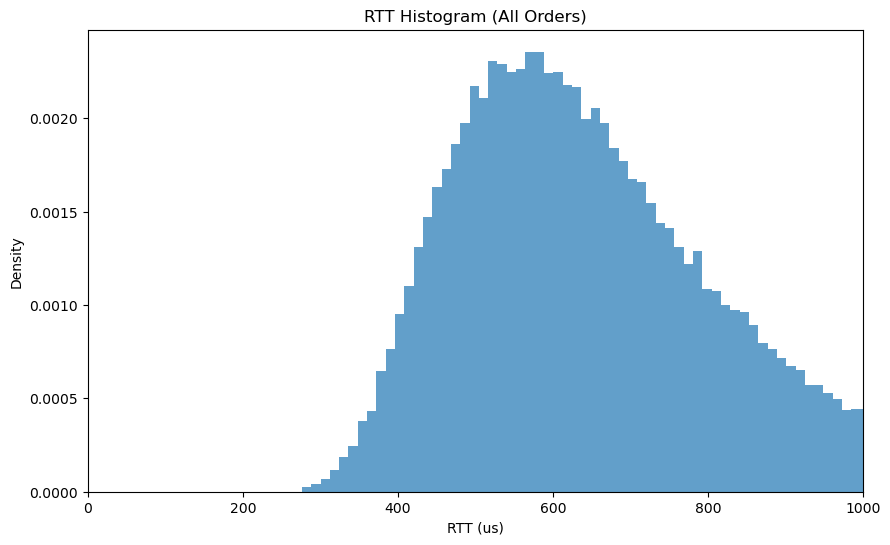

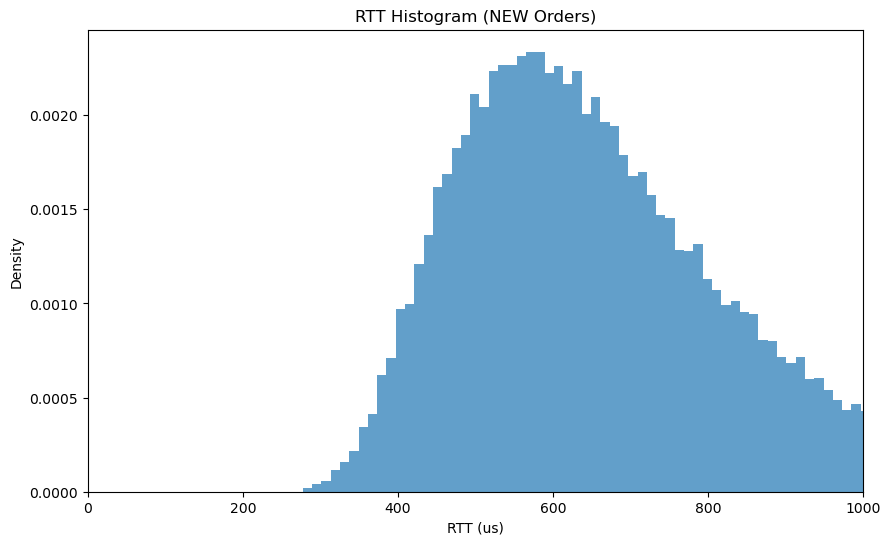

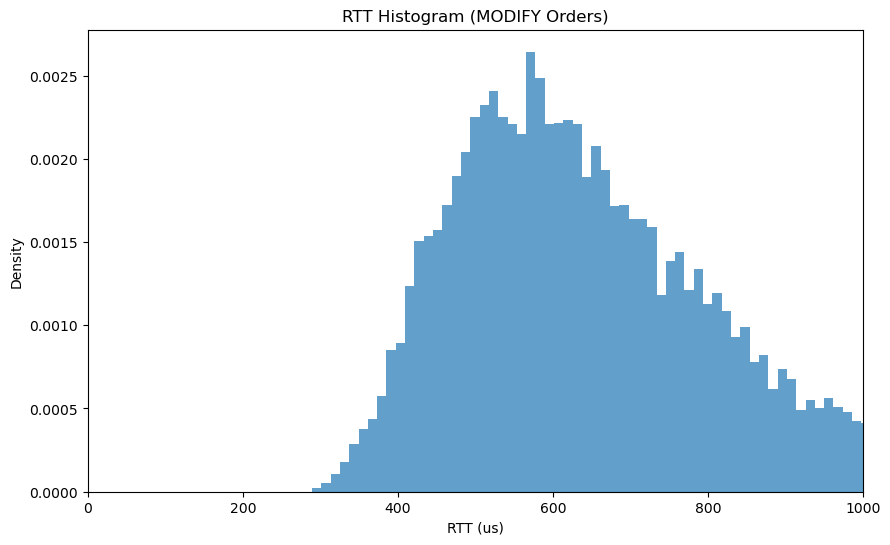

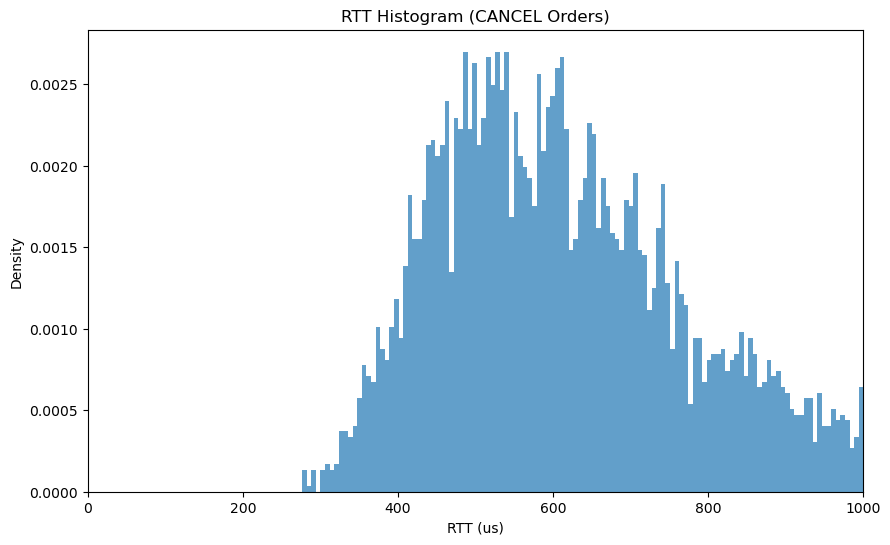

In [24]:

# Print metrics
print(f"Throughput: {throughput:.2f} orders/second")

import numpy as np
def print_stats(name, data):
    arr = np.array(data)
    print(f"{name}: count={len(arr)}, mean={arr.mean():.2f}us, p95={np.percentile(arr,95):.2f}us, p99={np.percentile(arr,99):.2f}us, max={arr.max():.2f}us")

print_stats("ALL", all_rtts)
for typ in all_type_rtts:
    print_stats(typ, all_type_rtts[typ])

import matplotlib.pyplot as plt

# Histogram for all RTTs with log scale and limited x-axis
plt.figure(figsize=(10,6))
plt.hist(all_rtts, bins=10000, alpha=0.7, density=True)
plt.title("RTT Histogram (All Orders)")
plt.xlabel("RTT (us)")
plt.ylabel("Density")
plt.xlim(0, 1000)  # Focus on main range, adjust as needed
plt.yscale('linear')  # Or use 'log' for y if needed
plt.show()

# Histogram for each type with log scale and limited x-axis
for typ in all_type_rtts:
    plt.figure(figsize=(10,6))
    plt.hist(all_type_rtts[typ], bins=10000, alpha=0.7, density=True)
    plt.title(f"RTT Histogram ({typ} Orders)")
    plt.xlabel("RTT (us)")
    plt.ylabel("Density")
    plt.xlim(0, 1000)  # Adjust as needed
    plt.show()
